In [1]:
#Does the average Body Mass Index (BMI) of players differ significantly between teams that advanced to the knockout stage (advanced) and teams that were eliminated in the group stage (eliminated) in the FIFA World Cup 2026?

#Data Sources & Documentation
#FB Ref (Primary Source for Player Physical Metrics):** https://fbref.com/en/
#FIFA Official Website (Tournament Statistics):** https://www.fifa.com/en/tournaments/mens/worldcup/canadamexicousa2026/statistics
#The Stats Don't Lie (Match & Team Outcomes):** https://www.thestatsdontlie.com/football/world-cup-2026/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Loaded the final sample dataset
df = pd.read_csv("FIFAWC2026_Final_Sample.csv")

#Check the first rows
print(df.head())

              player_name Pos  MP  Min  goals  height_cm  weight_kg      Team  \
0  Alexander Bernhardsson  MF   3  217      0        185         69    Sweden   
1           Jules KoundÃ©  DF   8  599      0        178         83    France   
2              Malo Gusto  DF   5  121      0        179         69    France   
3            Julio Enciso  FW   5  386      1        168         63  Paraguay   
4             Matt Turner  GK   1   90      0        191         83       USA   

  team_status        BMI  
0    advanced  20.160701  
1    advanced  26.196187  
2    advanced  21.534908  
3    advanced  22.321429  
4    advanced  22.751569  


In [3]:
#Set target sample per group
target_sample_size = 50

#Count player in advanced group
n_advanced_pop = len(df[df['team_status'] == 'advanced'])

#Count player in eliminated group
n_eliminated_pop = len(df[df['team_status'] == 'eliminated'])

#Adjust sample size if population is smaller than the target
sample_size = min(target_sample_size, n_advanced_pop, n_eliminated_pop)

if sample_size < target_sample_size:
  print(f"[Warning] Limited data available. Adjusting sample size per group to: {sample_size}")

#Split the populations
df_advanced_pop = df[df['team_status'] == 'advanced']
df_eliminated_pop = df[df['team_status'] == 'eliminated']

#Simple Random Sampling
sample_advanced = df_advanced_pop.sample(n=sample_size, random_state=42)
sample_eliminated = df_eliminated_pop.sample(n=sample_size, random_state=42)

#Combine samples for descriptive stats analysis
df_sample = pd.concat([sample_advanced, sample_eliminated])

print(f"Simple Random Sampling executed successfully:")
print(f"  - Advanced sample group size (n) = {len(sample_advanced)}")
print(f"  - Eliminated sample group size (n) = {len(sample_eliminated)}")


Simple Random Sampling executed successfully:
  - Advanced sample group size (n) = 50
  - Eliminated sample group size (n) = 50


In [4]:
#Analys for Descriptive Statistics
desc_stats = df_sample.groupby('team_status')['BMI'].describe()
print("==========================================================")
print("             DESCRIPTIVE STATISTICS FOR BMI               ")
print("==========================================================")
print(desc_stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])
print("==========================================================")


             DESCRIPTIVE STATISTICS FOR BMI               
             count       mean       std        min        25%        50%  \
team_status                                                                
advanced      50.0  23.052789  1.574890  19.925130  22.199265  22.767439   
eliminated    50.0  22.637332  1.457362  19.239475  21.385396  22.538412   

                   75%        max  
team_status                        
advanced     24.052273  26.543210  
eliminated   23.522948  26.989619  


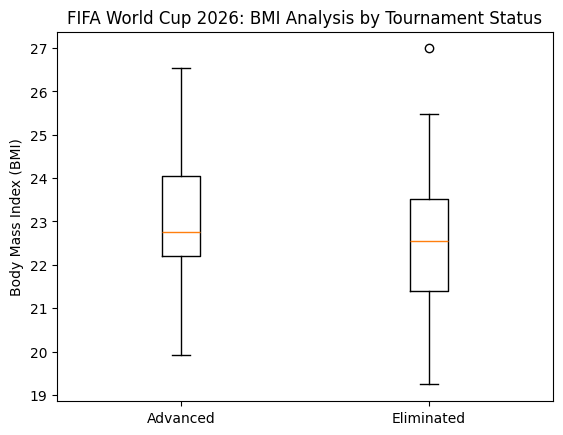

In [5]:
#Pull only the BMI column for separating the 2 groups
advanced_bmi = df_sample[df_sample['team_status'] == 'advanced']['BMI']
eliminated_bmi = df_sample[df_sample['team_status'] == 'eliminated']['BMI']

#Import 2 groups for preparing graph
data_to_plot = [
    advanced_bmi,
    eliminated_bmi
]

#Creating a boxplt to visually compare between the 2 groups
plt.boxplot(
    data_to_plot,
    tick_labels=["Advanced", "Eliminated"]
)

plt.title("FIFA World Cup 2026: BMI Analysis by Tournament Status")
plt.ylabel("Body Mass Index (BMI)")

plt.show()


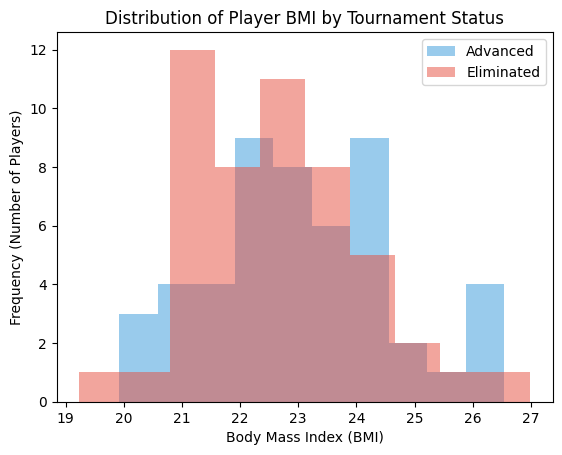

In [6]:
#Using a histogram to look at the distribution by groups
#Create a histogram for the advanced group
plt.hist(
    advanced_bmi,
    alpha=0.5,
    label="Advanced",
    color="#3498db"
)

#Create a histogram for the eliminated group
plt.hist(
    eliminated_bmi,
    alpha=0.5,
    label="Eliminated",
    color="#e74c3c"
)

plt.title("Distribution of Player BMI by Tournament Status")
plt.xlabel("Body Mass Index (BMI)")
plt.ylabel("Frequency (Number of Players)")
plt.legend()
plt.show()